In [6]:
import numpy as np
import pandas as pd
from collections import Counter
import os

In [ ]:
# title.basics.tsv 是一个 TSV (Tab-Separated Values) 文本文件，不是 NumPy 的 .npy 二进制文件
# 应该使用 pandas.read_csv 并指定分隔符为 '\t' 来读取
df = pd.read_csv("./imdb/title.basics.tsv", sep='\t', encoding='utf-8', on_bad_lines='skip')
# 确保 data2 文件夹存在
os.makedirs("data2", exist_ok=True)
# 提取文本列并转换为 ndarray
texts = df['primaryTitle'].astype(str).values
# 提取标签列（假设 'genres' 列可作为标签，可按需修改）
# 若需多标签可进一步处理，这里简单按字符串保存
labels = df['genres'].astype(str).values
print(f"Loaded {len(texts)} texts and {len(labels)} labels.")
print("Texts sample:", texts[:5])
print("Labels sample:", labels[:5])
# 保存为纯文本文件，每个样本写一行，特征和标签分开存，总计4个文件
# 保存训练集文本
with open("data2/train_texts.txt", "w", encoding="utf-8") as f:
    for line in texts:
        f.write(line + "\n")
# 保存训练集标签
with open("data2/train_labels.txt", "w", encoding="utf-8") as f:
    for line in labels:
        f.write(line + "\n")
# 保存验证集文本
with open("data2/val_texts.txt", "w", encoding="utf-8") as f:
    for line in texts:
        f.write(line + "\n")
# 保存验证集标签
with open("data2/val_labels.txt", "w", encoding="utf-8") as f:
    for line in labels:
        f.write(line + "\n")
print("已保存 train_texts.txt, train_labels.txt, val_texts.txt, val_labels.txt 到 data2 文件夹")
print("已保存 train_texts.txt, train_labels.txt, val_texts.txt, val_labels.txt 到 data 文件夹")


In [ ]:
!wc -l data2/train_texts.txt #统计训练集文本行数
!wc -l data2/val_texts.txt #统计验证集文本行数

 12342861 data/train_texts.txt
 12342861 data/val_texts.txt


# sub-word分词,构建词典(词根,词缀)

In [24]:
#!pip list|grep

In [ ]:
# !pip install subword-nmt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [subword-nmt]


In [ ]:
# 学习 BPE 码本和词汇表
# !subword-nmt learn-joint-bpe-and-vocab -i data2/imdb_train_texts.txt -o ./data2/imdb_bpe_code --write-vocabulary ./data2/imdb_bpe_vocab -s 8000
'''
imdb_bpe_code：BPE 合并规则，用于将文本编码为子词序列。
imdb_bpe_vocab：子词词汇表，包含所有子词及其出现次数。
'''

100%|#######################################| 8000/8000 [02:09<00:00, 62.01it/s]


'\nimdb_bpe_code：BPE 合并规则，用于将文本编码为子词序列。\nimdb_bpe_vocab：子词词汇表，包含所有子词及其出现次数。\n'

In [ ]:
# !subword-nmt apply-bpe -c ./data2/imdb_bpe_code -i ./data2/imdb_train_texts.txt -o ./data2/imdb_train_bpe.txt
# !subword-nmt apply-bpe -c ./data2/imdb_bpe_code -i ./data2/imdb_test_texts.txt -o ./data2/imdb_test_bpe.txt
'''
imdb_train_bpe.txt：训练集的子词序列，每个样本为一个子词序列。
imdb_test_bpe.txt：测试集的子词序列，每个样本为一个子词序列。
---
imdb_train_labels.txt：训练集的标签，每个样本为一个标签（0或1）。
imdb_test_labels.txt：测试集的标签，每个样本为一个标签（0或1）。
'''

'\nimdb_train_bpe.txt：训练集的子词序列，每个样本为一个子词序列。\nimdb_test_bpe.txt：测试集的子词序列，每个样本为一个子词序列。\nimdb_train_labels.txt：训练集的标签，每个样本为一个标签（0或1）。\nimdb_test_labels.txt：测试集的标签，每个样本为一个标签（0或1）。\n'

加载了8464个子词(包含特殊token)
共统计 12342861 条样本
平均长度: 5.43
最短长度: 1
最长长度: 193


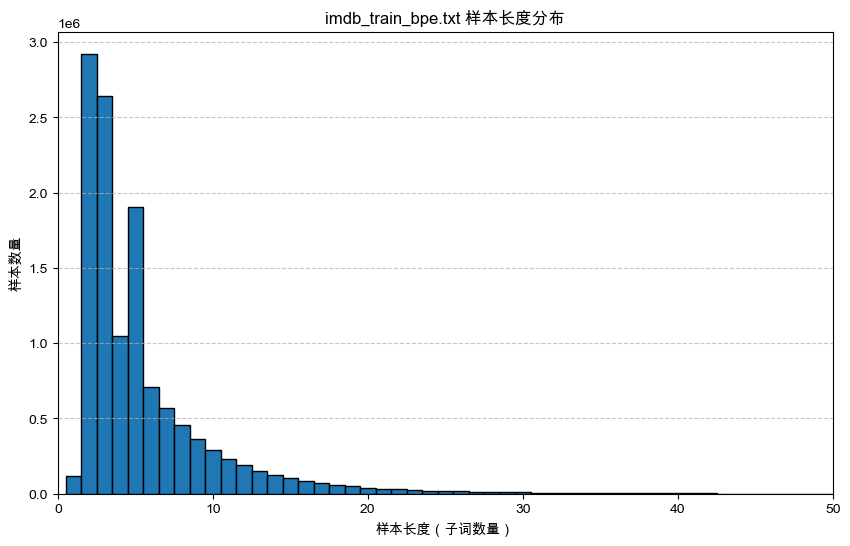

In [7]:
from collections import Counter

# 读取 imdb_bpe_vocab 文件并构建词典，保留词频 >= 1 的词条
bpe_vocab_path = "data2/imdb_bpe_vocab"  # BPE 词典文件路径

# 构建BPE词典
word2idx = {}  # 子词到索引的映射字典
idx2word = {}  # 索引到子词的映射字典
min_freq = 1  # 最小词频阈值，低于该频率的子词将被过滤

# 保留特殊token占用最前面的位置
special_tokens = ["<pad>", "<unk>", "<bos>", "<eos>"]  # 特殊标记列表
for idx, token in enumerate(special_tokens):  # 遍历特殊标记
    word2idx[token] = idx  # 将特殊标记写入 word2idx
    idx2word[idx] = token  # 将特殊标记写入 idx2word
nex_idx = len(special_tokens)  # 下一个可用索引，从特殊标记之后开始

with open(bpe_vocab_path, encoding="utf-8") as f:  # 打开 BPE 词典文件
    for line in f:  # 逐行读取
        if not line.strip():  # 跳过空行
            continue

        wordfreq = line.strip().split()  # 按空格分割词和频率
        if len(wordfreq) != 2:
            continue  # 格式不符则跳过
        word, freq = wordfreq  # 提取子词和频率
        freq = int(freq)  # 将频率字符串转为整数

        if freq >= min_freq:  # 频率满足阈值才保留
            """保证每个子词只映射到一个索引"""
            if word not in word2idx:  # 如果子词不在词典中
                word2idx[word] = nex_idx  # 子词映射到当前索引
                idx2word[nex_idx] = word  # 当前索引映射到子词
                nex_idx += 1  # 索引自增，为下一个子词准备


voca_size = len(word2idx)  # 计算词典大小（含特殊标记）
print(f"加载了{voca_size}个子词(包含特殊token)")  # 打印加载结果

# 统计 imdb_train_bpe.txt 中每条样本的长度并绘制柱状图
import matplotlib.pyplot as plt

# 设置中文显示
plt.rcParams["font.family"] = "Arial Unicode MS"
plt.rcParams["axes.unicode_minus"] = False

train_bpe_path = "data2/imdb_train_bpe.txt"  # BPE 训练文件路径
lengths = []  # 用于保存每条样本的子词数量

with open(train_bpe_path, encoding="utf-8") as f:  # 打开训练文件
    for line in f:  # 逐行读取
        line = line.strip()
        if not line:  # 跳过空行
            continue
        tokens = line.split()  # 按空格分割得到子词列表
        lengths.append(len(tokens))  # 记录当前样本的子词数量

# 打印统计信息
print(f"共统计 {len(lengths)} 条样本")
print(f"平均长度: {sum(lengths)/len(lengths):.2f}")
print(f"最短长度: {min(lengths)}")
print(f"最长长度: {max(lengths)}")

# 绘制长度分布柱状图（仅展示0-50范围）
length_counts = Counter(lengths)  # 统计每个长度出现的次数
lengths_sorted = sorted(
    [l for l in length_counts.keys() if 0 <= l <= 50]
)  # 仅保留0-50范围内的长度并排序
counts = [length_counts[l] for l in lengths_sorted]  # 对应出现次数

plt.figure(figsize=(10, 6))
plt.bar(lengths_sorted, counts, width=1.0, edgecolor="black")
plt.xlabel("样本长度（子词数量）")
plt.ylabel("样本数量")
plt.title("imdb_train_bpe.txt 样本长度分布")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.xlim(0, 50)  # 限制x轴范围为0-50
plt.show()

# Token

In [8]:
#word-level分词,左右除去空格
def word_level_tokenize(text):
    return text.strip().split()


In [9]:
def load_data(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return f.readlines()
    
#变成列表    
train_texts = load_data('data2/imdb_train_bpe.txt')
train_labels = load_data('data2/imdb_train_labels.txt')
test_texts = load_data('data2/imdb_test_bpe.txt')
test_labels = load_data('data2/imdb_test_labels.txt')


In [2]:
class Tokenizer:
    def __init__(self, word2idx, idx2word=None, max_len=None):
        self.word2idx = word2idx
        # 如果传入了 idx2word，则使用传入的，否则根据 word2idx 生成
        if idx2word:
            self.idx2word = idx2word
        else:
            self.idx2word = {v: k for k, v in word2idx.items()}
            
        self.max_len = max_len
        self.pad_token = "<pad>"
        self.unk_token = "<unk>"
        # 获取 pad 和 unk 的 id，如果词表中没有，默认为 0 和 1
        self.pad_id = self.word2idx.get(self.pad_token, 0)
        self.unk_id = self.word2idx.get(self.unk_token, 1)

    def encode(self, texts, padding_first=False):
        """
        将文本列表编码为索引序列
        :param texts: 文本列表，每个元素是一个字符串（词之间用空格分隔）
        :param padding_first: 是否在前面填充
        :return: 索引列表的列表
        """
        batch_ids = []
        for text in texts:
            tokens = text.strip().split()
            ids = [self.word2idx.get(token, self.unk_id) for token in tokens]
            
            if self.max_len:
                if len(ids) > self.max_len:
                    # 截断（这里简单地截取后面部分，也可以根据需求截取前面）
                    ids = ids[:self.max_len]
                else:
                    # 填充
                    pad_len = self.max_len - len(ids)
                    if padding_first:
                        ids = [self.pad_id] * pad_len + ids
                    else:
                        ids = ids + [self.pad_id] * pad_len
            batch_ids.append(ids)
        return batch_ids

    def decode(self, batch_ids):
        """
        将索引序列解码为文本
        :param batch_ids: 索引列表的列表
        :return: 文本列表
        """
        decoded_texts = []
        for ids in batch_ids:
            tokens = [self.idx2word.get(idx, self.unk_token) for idx in ids]
            # 过滤掉 pad_token
            tokens = [t for t in tokens if t != self.pad_token]
            # 还原时子词通常带有 @@ 后缀表示未结束，这里简单拼接
            text = " ".join(tokens).replace("@@ ", "")
            decoded_texts.append(text)
        return decoded_texts

# 实例化 Tokenizer
tokenizer = Tokenizer(word2idx, idx2word=idx2word, max_len=None)

# 测试 Tokenizer
sample_text = "the movie was good"
# 模拟 batch 输入，即使只有一个样本也要放入列表
encoded = tokenizer.encode([sample_text])
decoded = tokenizer.decode(encoded)

print(f"Original: {sample_text}")
print(f"Encoded: {encoded}")
print(f"Decoded: {decoded}")

NameError: name 'word2idx' is not defined

In [10]:
# 使用readlines读取data2/imdb_train_bpe.txt
with open("data2/imdb_train_bpe.txt", "r", encoding="utf-8") as f:
    train_texts = f.readlines()


# 实例化tokenizer对象
tokenizer = Tokenizer(word2idx, idx2word, max_len=500)

# 对每个样本encode
batch_token_ids = tokenizer.encode(train_texts[0:3], padding_first=True)
print("\nencode after token id:")
for i, tids in enumerate(batch_token_ids):
    print(f"样本 {i+1} token ids :{tids}")
    print(f"样本 {i+1} 长度 :{len(tids)}")
print("-" * 100)

decoded_texts = tokenizer.decode(batch_token_ids)
print("\ndecode after token id:")
for i, text in enumerate(decoded_texts):
    print(f"样本 {i+1} 解码文本 :{text}")


encode after token id:
样本 1 token ids :[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,

# DataSet 和 Dataloader

In [19]:
import torch
from torch.utils.data import Dataset, DataLoader

# 构建标签词典
all_labels = [label.strip() for label in train_labels]
unique_labels = sorted(list(set(all_labels)))
label2idx = {label: idx for idx, label in enumerate(unique_labels)}
idx2label = {idx: label for label, idx in label2idx.items()}
print(f"标签词典大小: {len(label2idx)}")

class ImdbDataset(Dataset):
    def __init__(self, texts, labels, label2idx, max_len=None):
        self.texts = texts
        self.labels = labels
        self.label2idx = label2idx
        self.max_len = max_len
        
    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text=self.texts[idx]
        label=self.labels[idx].strip()
        label_id = self.label2idx.get(label, 0)
        return {'text':text,'labels':label_id}



标签词典大小: 2386


In [20]:
def collate_fn(batch):
    """
    DataLoader 的 collate_fn，用于将一个 batch 的样本打包成 Tensor
    """
    '''
    不应该exts, labels = zip(*batch)
    不应该使用zip(*batch)来解包batch, 因为batch中的每个样本都是一个字典, 
    而zip(*batch)会将每个字典的键值对解包成一个元组, 而不是一个样本
    '''
    texts = [item['text'] for item in batch]
    labels = [item['labels'] for item in batch]
    
    # 注意：这里需要在外部访问 tokenizer 对象
    batch_token_ids = tokenizer.encode(texts, padding_first=True)
    
    # 转换为 Tensor
    input_ids = torch.tensor(batch_token_ids, dtype=torch.long)
    '''张量不可以批量转换为Python标量,需要使用int()来转换每个元素'''
    labels=torch.tensor(labels, dtype=torch.long)
    # labels = torch.tensor([int(l.strip()) for l in labels], dtype=torch.long)
    return {'input_ids': input_ids, 'labels': labels}

# 实例化 
batch_size = 64

train_dataset = ImdbDataset(train_texts,train_labels, label2idx)
test_dataset=ImdbDataset(test_texts,test_labels, label2idx)
for d in train_dataset:
    print(d['text'])
    print(d['labels'])
    break



Car@@ m@@ enc@@ ita

1604


In [23]:
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

# 测试 DataLoader
'''ValueError: too many dimensions 'str'''
for batch in train_dataloader:
    print("input_ids shape:", batch['input_ids'].shape)
    if isinstance(batch['labels'], torch.Tensor):
        print("labels shape:", batch['labels'].shape)
    print(type(batch)) 
    break

for batch in test_dataloader:
    print("input_ids shape:", batch['input_ids'].shape)
    if isinstance(batch['labels'], torch.Tensor):
        print("labels shape:", batch['labels'].shape)
    print(type(batch)) 
    break


input_ids shape: torch.Size([64, 500])
labels shape: torch.Size([64])
<class 'dict'>
input_ids shape: torch.Size([64, 500])
labels shape: torch.Size([64])
<class 'dict'>


# 搭建模型